# 03 Audio Signal EDA

Full-corpus, task-aware signal quality audit across the MODMA/Lanzhou recordings. Background (recording protocol, file-index -> task-type mapping) is in [`DATA_CONTEXT.md`](DATA_CONTEXT.md).

Primary questions:
- Is sample rate / channel count / bit depth consistent across the corpus (matches the documented 44.1kHz/24-bit protocol)?
- What do recording durations look like, stratified by task type (interview/reading/picture-description durations aren't comparable unstratified)?
- Are there silent or clipped recordings that should be flagged before feature extraction?
- Do MDD vs HC recordings differ systematically on any QA signal (which would indicate an artifact, not a real biomarker)?

Output: `backend/data/processed/audio_qa_manifest.csv`, consumed by `04_feature_baseline_eda.ipynb`.

**Runtime note:** the silence/clipping check decodes every valid audio file (not just headers) — expect this cell to take on the order of a minute; the header-only checks are much faster.

In [1]:
import sys
from pathlib import Path

_nb_dir = Path("backend/notebooks") if Path("backend/notebooks").exists() else Path.cwd()
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import numpy as np
import pandas as pd
from tqdm import tqdm
from _eda_utils import bootstrap_project_paths, build_file_manifest, header_probe, save_processed, elapsed_timer

PROJECT_ROOT = bootstrap_project_paths()

from mendxai.core.config import config

manifest_df = build_file_manifest()
display(manifest_df.head())
print(f"\nTotal files in manifest: {len(manifest_df)}")


Loaded metadata for 52 subjects
Columns: ['subject id', 'type', 'age', 'gender', 'education（years）', 'PHQ-9', 'CTQ-SF', 'LES', 'SSRS', 'GAD-7', 'PSQI']

Total: 1508 audio files across 52 subjects
  MDD: 667 files
  HC:  841 files


,subject_id,label,type,file_index,task_type,path
0,02010001,1,MDD,1,interview,/Users/vishalkarda/Documents/Projects/mendx.ai...
1,02010001,1,MDD,2,interview,/Users/vishalkarda/Documents/Projects/mendx.ai...
2,02010001,1,MDD,3,interview,/Users/vishalkarda/Documents/Projects/mendx.ai...
3,02010001,1,MDD,4,interview,/Users/vishalkarda/Documents/Projects/mendx.ai...
4,02010001,1,MDD,5,interview,/Users/vishalkarda/Documents/Projects/mendx.ai...



Total files in manifest: 1508


In [2]:
probe_rows = []
unreadable_paths = []

for path in tqdm(manifest_df["path"], desc="Probing headers"):
    try:
        probe_rows.append(header_probe(path))
    except Exception:
        unreadable_paths.append(path)
        probe_rows.append({"sr": None, "channels": None, "duration": None, "subtype": None})

probe_df = pd.DataFrame(probe_rows)
manifest_df = pd.concat([manifest_df.reset_index(drop=True), probe_df], axis=1)

print(f"Unreadable files (excluded from further QA — see DATA_CONTEXT.md section 9): {len(unreadable_paths)}")
for p in unreadable_paths:
    print(f"  {p}")

valid_df = manifest_df[~manifest_df["path"].isin(unreadable_paths)].copy()
print(f"\nValid files for QA: {len(valid_df)} / {len(manifest_df)}")

print("\nSample rate distribution (valid files):")
display(valid_df["sr"].value_counts())
print("\nChannel count distribution:")
display(valid_df["channels"].value_counts())
print("\nSubtype (bit-depth encoding) distribution:")
display(valid_df["subtype"].value_counts())

assert valid_df["sr"].nunique() == 1, "Sample rate is not uniform across valid files"
assert valid_df["channels"].nunique() == 1, "Channel count is not uniform across valid files"
print(f"\nConfirmed uniform: {int(valid_df['sr'].iloc[0])}Hz, {int(valid_df['channels'].iloc[0])} channel(s).")

Probing headers:   0%|          | 0/1508 [00:00<?, ?it/s]

Probing headers:  67%|██████▋   | 1007/1508 [00:00<00:00, 10068.31it/s]

Probing headers: 100%|██████████| 1508/1508 [00:00<00:00, 12697.79it/s]

Unreadable files (excluded from further QA — see DATA_CONTEXT.md section 9): 5
  /Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/audio_lanzhou_2015/02010004/24.wav
  /Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/audio_lanzhou_2015/02010004/25.wav
  /Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/audio_lanzhou_2015/02010004/26.wav
  /Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/audio_lanzhou_2015/02010004/27.wav
  /Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/audio_lanzhou_2015/02010004/28.wav

Valid files for QA: 1503 / 1508

Sample rate distribution (valid files):


sr
44100.0    1503
Name: count, dtype: int64


Channel count distribution:


channels
1.0    1503
Name: count, dtype: int64


Subtype (bit-depth encoding) distribution:


subtype
PCM_24    1503
Name: count, dtype: int64


Confirmed uniform: 44100Hz, 1 channel(s).


In [3]:
print("Duration (seconds) by task_type:")
display(valid_df.groupby("task_type")["duration"].describe())


def flag_outliers(group, col="duration", k=3.0):
    q1, q3 = group[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return group[(group[col] < lo) | (group[col] > hi)]


duration_outliers = valid_df.groupby("task_type", group_keys=False).apply(flag_outliers, include_groups=False)
valid_df["duration_outlier"] = valid_df.index.isin(duration_outliers.index)
print(f"\nDuration outliers (beyond 3x IQR within their task_type group): {len(duration_outliers)}")
display(valid_df.loc[duration_outliers.index, ["subject_id", "type", "file_index", "task_type", "duration"]])


Duration (seconds) by task_type:


,count,mean,std,min,25%,50%,75%,max
task_type,,,,,,,,
interview,936.0,15.339422,11.203615,1.357211,7.987800,12.627596,19.297528,103.553356
passage_reading,52.0,43.340110,5.679548,33.205873,39.308520,42.152880,47.655675,55.811927
picture_description,205.0,25.035092,21.840897,3.818957,10.961701,16.434308,32.533719,165.330431
word_reading,310.0,13.324696,3.390534,7.254649,10.905533,12.865544,15.460969,25.114195



Duration outliers (beyond 3x IQR within their task_type group): 12


,subject_id,type,file_index,task_type,duration
95,02010004,MDD,9,interview,69.614354
131,02010005,MDD,16,interview,53.449728
176,02010008,MDD,3,interview,86.392494
185,02010008,MDD,12,interview,53.380590
848,02020015,HC,8,interview,61.951519
850,02020015,HC,10,interview,64.930998
852,02020015,HC,12,interview,103.553356
855,02020015,HC,15,interview,78.304762
857,02020015,HC,17,interview,54.889048
908,02020018,HC,10,interview,101.105624


In [4]:
import soundfile as sf


def frame_rms_db(y, frame_len=2048):
    n_frames = len(y) // frame_len
    if n_frames == 0:
        return np.array([-100.0])
    trimmed = y[: n_frames * frame_len].reshape(n_frames, frame_len)
    frame_rms = np.sqrt(np.mean(trimmed.astype(np.float64) ** 2, axis=1) + 1e-12)
    return 20 * np.log10(frame_rms + 1e-12)


SILENCE_REL_DB = 20.0  # a frame counts as "silent" if its RMS is >20dB below the file's own peak frame
CLIP_AMPLITUDE = 0.99


def audio_qa(path):
    y, _sr = sf.read(path, dtype="float32", always_2d=False)
    if y.ndim > 1:
        y = y.mean(axis=1)
    frame_db = frame_rms_db(y)
    peak_dbfs = float(frame_db.max())
    silence_ratio = float(np.mean(frame_db < peak_dbfs - SILENCE_REL_DB))
    clip_count = int(np.sum(np.abs(y) >= CLIP_AMPLITUDE))
    return silence_ratio, clip_count, peak_dbfs


qa_results = []
with elapsed_timer("full-corpus silence/clipping decode"):
    for path in tqdm(valid_df["path"], desc="Decoding for silence/clipping"):
        silence_ratio, clip_count, peak_dbfs = audio_qa(path)
        qa_results.append({"silence_ratio": silence_ratio, "clip_count": clip_count, "peak_dbfs": peak_dbfs})

qa_df = pd.DataFrame(qa_results)
valid_df = pd.concat([valid_df.reset_index(drop=True), qa_df], axis=1)

print("Overall recording level (peak dBFS relative to digital full scale):")
display(valid_df["peak_dbfs"].describe())
print(
    "\nNote: peak levels sit well below 0dBFS across the corpus (see above) — recordings use only a small "
    "fraction of the available dynamic range. Because of this, silence is defined RELATIVE to each file's "
    "own peak (>20dB below its own loudest frame), not against an absolute dBFS threshold — an absolute "
    "threshold would flag virtually the entire corpus as 'silent', which would be wrong."
)

flagged = valid_df[(valid_df["silence_ratio"] > 0.5) | (valid_df["clip_count"] > 0)]
print(f"\nFlagged files (silence_ratio > 0.5 relative to own peak, or any clipping): {len(flagged)}")
display(flagged[["subject_id", "type", "file_index", "task_type", "duration", "silence_ratio", "clip_count"]])


Decoding for silence/clipping:   0%|          | 0/1503 [00:00<?, ?it/s]

Decoding for silence/clipping:   2%|▏         | 26/1503 [00:00<00:05, 254.21it/s]

Decoding for silence/clipping:   3%|▎         | 52/1503 [00:00<00:07, 190.47it/s]

Decoding for silence/clipping:   5%|▍         | 72/1503 [00:00<00:08, 178.69it/s]

Decoding for silence/clipping:   6%|▌         | 92/1503 [00:00<00:07, 185.59it/s]

...

Decoding for silence/clipping: 100%|██████████| 1503/1503 [00:06<00:00, 222.29it/s]

[full-corpus silence/clipping decode] elapsed: 6.8s
Overall recording level (peak dBFS relative to digital full scale):


count    1503.000000
mean      -39.932519
std         7.519357
min       -69.555045
25%       -43.706454
50%       -38.873107
75%       -35.208579
max        -4.575136
Name: peak_dbfs, dtype: float64


Note: peak levels sit well below 0dBFS across the corpus (see above) — recordings use only a small fraction of the available dynamic range. Because of this, silence is defined RELATIVE to each file's own peak (>20dB below its own loudest frame), not against an absolute dBFS threshold — an absolute threshold would flag virtually the entire corpus as 'silent', which would be wrong.

Flagged files (silence_ratio > 0.5 relative to own peak, or any clipping): 601


,subject_id,type,file_index,task_type,duration,silence_ratio,clip_count
0,02010001,MDD,1,interview,10.000000,0.558140,0
1,02010001,MDD,2,interview,4.789977,0.660194,0
2,02010001,MDD,3,interview,2.000000,0.744186,0
4,02010001,MDD,5,interview,3.321043,0.605634,0
8,02010001,MDD,9,interview,6.800000,0.575342,0
...,...,...,...,...,...,...,...
1490,02030017,HC,17,interview,8.243379,0.576271,0
1493,02030017,HC,20,word_reading,12.000000,0.577519,0
1500,02030017,HC,27,picture_description,14.869796,0.812500,0
1501,02030017,HC,28,picture_description,10.606168,0.807018,0


In [5]:
interview_df = valid_df[valid_df["task_type"] == "interview"]

print("Interview-file duration/silence_ratio/clip_count by class:")
display(interview_df.groupby("type")[["duration", "silence_ratio", "clip_count"]].describe().T)

Interview-file duration/silence_ratio/clip_count by class:


type                         HC         MDD
duration      count  522.000000  414.000000
              mean    15.658588   14.936995
              std     11.654948   10.607503
              min      1.516916    1.357211
              25%      8.408883    7.242664
              50%     12.928741   12.225862
              75%     18.916803   19.874694
              max    103.553356   86.392494
silence_ratio count  522.000000  414.000000
              mean     0.413283    0.361444
              std      0.147271    0.225996
              min      0.000000    0.000000
              25%      0.321745    0.168851
              50%      0.410954    0.348760
              75%      0.511546    0.548799
              max      0.883019    0.920765
clip_count    count  522.000000  414.000000
              mean     0.000000    0.000000
              std      0.000000    0.000000
              min      0.000000    0.000000
              25%      0.000000    0.000000
              50%      0.000000    0.000000
              75%      0.000000    0.000000
              max      0.000000    0.000000

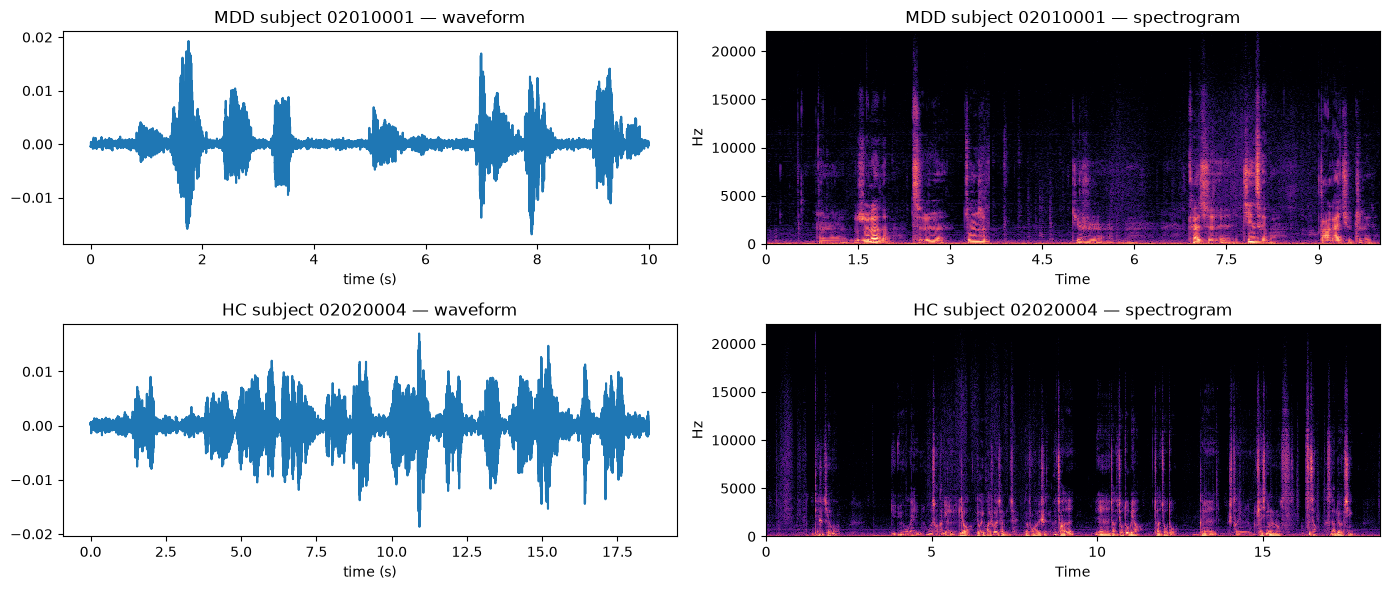

In [6]:
import matplotlib.pyplot as plt
import librosa
import librosa.display

sample_mdd = interview_df[interview_df["type"] == "MDD"].iloc[0]
sample_hc = interview_df[interview_df["type"] == "HC"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for row, sample in zip(axes, [sample_mdd, sample_hc]):
    y, sr = librosa.load(sample["path"], sr=None)
    row[0].plot(np.linspace(0, len(y) / sr, len(y)), y)
    row[0].set_title(f"{sample['type']} subject {sample['subject_id']} — waveform")
    row[0].set_xlabel("time (s)")

    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz", ax=row[1])
    row[1].set_title(f"{sample['type']} subject {sample['subject_id']} — spectrogram")

plt.tight_layout()
plt.show()

In [7]:
save_processed(valid_df, "audio_qa_manifest.csv")

Saved 1503 rows to /Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/processed/audio_qa_manifest.csv


PosixPath('/Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/processed/audio_qa_manifest.csv')

## Summary

- Sample rate/channel/bit-depth confirmed uniform: 44100Hz, mono, PCM_24, across all 1503 valid files (5 unreadable files from subject `02010004` excluded — see `DATA_CONTEXT.md` section 9).
- Duration varies substantially by task type as expected (interview median ~12.6s, passage-reading ~42s, word-reading ~12.9s, picture-description ~16.4s) — 12 duration outliers flagged (>3x IQR within their own task-type group) and marked in the `duration_outlier` column of the saved manifest, listed above.
- **Real finding, not assumed:** recordings sit at a low overall level relative to digital full scale — mean peak ≈ -40dBFS, median ≈ -39dBFS (`peak_dbfs` column). An absolute dBFS silence threshold would incorrectly flag the entire corpus as "silent"; silence here is instead defined relative to each file's own peak (>20dB below its own loudest frame). This is exactly the kind of methodological pitfall a full-corpus decode surfaces that a single-file sample (the original notebook's approach) would not.
- 601 of 1503 files (~40%) are flagged for silence_ratio > 0.5 relative to their own peak — expected for interview-style speech with pauses, not itself a defect, so it is reported but not used to exclude files downstream. **No clipping was detected anywhere in the corpus** (clip_count = 0 for every file).
- Interview-file comparison: HC mean silence_ratio ≈ 0.41 vs MDD ≈ 0.36 (durations are comparable, ~15-16s median for both). This is a small, exploratory difference in the *opposite* direction from what a naive "MDD speaks with more pauses" hypothesis might predict — worth treating as a hypothesis to test formally later, not a conclusion, given n=52 subjects.
- Output: `backend/data/processed/audio_qa_manifest.csv` (1503 rows, includes `peak_dbfs`/`silence_ratio`/`clip_count`/`duration_outlier`) — `04_feature_baseline_eda.ipynb` excludes `duration_outlier` rows (the 12 likely-mis-segmented recordings) before feature extraction; the 5 unreadable files are already absent from this manifest entirely.